# Multi-Turn Conversation Jailbreak Detector with Local Outlier Factor (LOF)

---
## 1. Install & Import Dependencies

In [ ]:

lof_report ={}

In [74]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, confusion_matrix,
                              f1_score, accuracy_score,
                              precision_score, recall_score)
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False


In [75]:
conv_id=0

In [76]:
JSON_PATH = "../data/raw/conversation_multiTurn_scaleAI.json"


with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)
print(f"Loaded {len(raw_data)} conversations from {JSON_PATH}")

records = []
for conv in raw_data:
    qid =conv_id
    conv_id += 1
    for turn in conv["turns"]:
        user_text   = turn.get("attack_message", "")
        assist_text = turn.get("target_response", "")
        records.append({
            "conv_id" : qid,
            "round": turn.get("turn", None),
            "user_text" : user_text,
            "assistant_text": assist_text,
            "full_turn": f"{user_text} {assist_text}",
            "label"    : turn.get("judge_result", -1)
        })

df = pd.DataFrame(records)
print(f"Total turns:{len(df)}")
print(f"Total convs:{df['conv_id'].nunique()}")
print(f"Malicious :{(df['label']==1).sum()}")
print(f"Benign: {(df['label']==0).sum()}")
print(df[["conv_id","round","label"]].head(10).to_string())


Loaded 389 conversations from ../data/raw/conversation_multiTurn_scaleAI.json
Total turns:920
Total convs:389
Malicious :323
Benign: 597
   conv_id  round  label
0        0      1      0
1        0      2      1
2        1      1      0
3        1      2      0
4        1      3      0
5        1      4      1
6        2      1      0
7        2      2      1
8        3      1      1
9        4      1      1


In [77]:
JSON_PATH = "../data/raw/multi_turn_conversations_from_opposite_day_08.json"


with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)
print(f"Loaded {len(raw_data)} conversations from {JSON_PATH}")


for conv in raw_data:
    qid = conv_id
    conv_id += 1
    for turn in conv["conversation"]:
        user_text   = turn.get("user", "")
        assist_text = turn.get("assistant", "")
        records.append({
            "conv_id"       : qid,
            "round"         : turn.get("round", None),
            "user_text"     : user_text,
            "assistant_text": assist_text,
            "full_turn"     : f"{user_text} {assist_text}",
            "label"         : turn.get("label", -1)
        })

df = pd.DataFrame(records)
print(f"Total turns  : {len(df)}")
print(f"Total convs  : {df['conv_id'].nunique()}")
print(f"Malicious    : {(df['label']==1).sum()}")
print(f"Benign       : {(df['label']==0).sum()}")
print(df[["conv_id","round","label"]].head(10).to_string())


Loaded 143 conversations from ../data/raw/multi_turn_conversations_from_opposite_day_08.json
Total turns  : 1294
Total convs  : 532
Malicious    : 497
Benign       : 797
   conv_id  round  label
0        0      1      0
1        0      2      1
2        1      1      0
3        1      2      0
4        1      3      0
5        1      4      1
6        2      1      0
7        2      2      1
8        3      1      1
9        4      1      1


In [78]:
JSON_PATH = "../data/raw/multi_turn_conversations_from_crescendomation_08.json"


with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)
print(f"Loaded {len(raw_data)} conversations from {JSON_PATH}")


for conv in raw_data:
    qid = conv_id
    conv_id += 1
    for turn in conv["conversation"]:
        user_text   = turn.get("user", "")
        assist_text = turn.get("assistant", "")
        records.append({
            "conv_id"       : qid,
            "round"         : turn.get("round", None),
            "user_text"     : user_text,
            "assistant_text": assist_text,
            "full_turn"     : f"{user_text} {assist_text}",
            "label"         : turn.get("label", -1)
        })

df = pd.DataFrame(records)
print(f"Total turns  : {len(df)}")
print(f"Total convs  : {df['conv_id'].nunique()}")
print(f"Malicious    : {(df['label']==1).sum()}")
print(f"Benign       : {(df['label']==0).sum()}")
print(df[["conv_id","round","label"]].head(10).to_string())

lof_report["data_summary"] = {
    "total_turns": len(df),
    "total_convs": df['conv_id'].nunique(),
    "malicious": (df['label']==1).sum(),
    "benign": (df['label']==0).sum()
}

Loaded 277 conversations from ../data/raw/multi_turn_conversations_from_crescendomation_08.json
Total turns  : 1984
Total convs  : 809
Malicious    : 897
Benign       : 1087
   conv_id  round  label
0        0      1      0
1        0      2      1
2        1      1      0
3        1      2      0
4        1      3      0
5        1      4      1
6        2      1      0
7        2      2      1
8        3      1      1
9        4      1      1


In [79]:
BENIGN_PATH = "../data/raw/benign_data.jsonl" 

benign_records = []

with open(BENIGN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        item = json.loads(line)
        
        id=conv_id 
        conv_id+=1  
        convs     = item["conversations"]
        
     
        i = 0
        turn_num = 1
        while i < len(convs):
            user_text   = ""
            assist_text = ""
            
            if i < len(convs) and convs[i]["from"] == "human":
                user_text = convs[i]["value"]
                i += 1
            
            if i < len(convs) and convs[i]["from"] == "gpt":
                assist_text = convs[i]["value"]
                i += 1
            
            if not user_text and not assist_text:
                continue
            
            benign_records.append({
                "conv_id"       : id,
                "round"         : turn_num,
                "user_text"     : user_text,
                "assistant_text": assist_text,
                "full_turn"     : f"{user_text} {assist_text}",
                "label"         : 0    #all benign
            })
            turn_num += 1

benign_df = pd.DataFrame(benign_records)
print(f"Benign conversations : {benign_df['conv_id'].nunique()}")
print(f"Benign turns         : {len(benign_df)}")
print(benign_df[["conv_id","round","label"]].head(10).to_string())

Benign conversations : 297
Benign turns         : 1519
   conv_id  round  label
0      809      1      0
1      809      2      0
2      809      3      0
3      809      4      0
4      809      5      0
5      809      6      0
6      810      1      0
7      810      2      0
8      810      3      0
9      810      4      0


In [80]:
df_original = df.copy()  

df = pd.concat([df_original, benign_df], ignore_index=True)


print("\nCombined dataset:")
print(f"Total turns : {len(df)}")
print(f"Total conversations: {df['conv_id'].nunique()}")
print(f"Malicious turns: {(df['label']==1).sum()}")
print(f"Benign turns: {(df['label']==0).sum()}")
print(f" Unlabeled turns: {(df['label']==-1).sum()}")
lof_report["combined_data_summary"] = {
    "total_turns": len(df),
    "total_convs": df['conv_id'].nunique(),
    "malicious": (df['label']==1).sum(),
    "benign": (df['label']==0).sum(),
    "unlabeled": (df['label']==-1).sum()
}



Combined dataset:
Total turns : 3503
Total conversations: 1106
Malicious turns: 897
Benign turns: 2606
 Unlabeled turns: 0


---
## 3. Embed Turns with Sentence Transformers


In [81]:
print("Loading sentence embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding turns...")
embeddings = embedder.encode(
    df["full_turn"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)


Loading sentence embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 227.33it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding turns...


Batches: 100%|██████████| 110/110 [02:00<00:00,  1.09s/it]



## Kernel PCA


using an RBF kernel:

K(xi,xj	​)=exp(−γ∣∣xi−xj∣∣2)

In [82]:

from sklearn.preprocessing import RobustScaler


n_samples= embeddings.shape[0]
n_components= min(50, n_samples - 1)
scaler_emb= RobustScaler()
emb_scaled= scaler_emb.fit_transform(embeddings)
kpca = KernelPCA(n_components=n_components, kernel="rbf", random_state=42)
emb_reduced= kpca.fit_transform(emb_scaled)


X_combined = np.hstack([emb_reduced])

lof_report["feature_shapes"] = {
    "embeddings": embeddings.shape,
    "combined": X_combined.shape
}   


## 5. Ensemble Detection (LOF + Isolation Forest)


In [83]:
from sklearn.model_selection import train_test_split


conv_labels = (
    df[df["label"] != -1]
    .groupby("conv_id")["label"]
    .max()
    .reset_index()
)
conv_labels.columns = ["conv_id", "conv_label"]

train_conv_ids, test_conv_ids = train_test_split(
    conv_labels["conv_id"],
    test_size=0.2,
    random_state=42,
    stratify=conv_labels["conv_label"]   
)

train_conv_ids = set(train_conv_ids)
test_conv_ids  = set(test_conv_ids)

train_mask = df["conv_id"].isin(train_conv_ids) & (df["label"] != -1)
test_mask  = df["conv_id"].isin(test_conv_ids)  & (df["label"] != -1)

train_idx = df[train_mask].index
test_idx  = df[test_mask].index

y_train = df.loc[train_idx, "label"].values
y_test  = df.loc[test_idx,  "label"].values

X_train = X_combined[train_mask.values]
X_test  = X_combined[test_mask.values]

print(f"Train conversations : {len(train_conv_ids)}")
print(f"Test  conversations : {len(test_conv_ids)}")
print(f"Train turns         : {len(y_train)}  "
      f"(malicious={y_train.sum()}, benign={(y_train==0).sum()})")
print(f"Test  turns         : {len(y_test)}   "
      f"(malicious={y_test.sum()}, benign={(y_test==0).sum()})")

REAL_MALICIOUS_RATIO = y_train.sum() / len(y_train)
print(f"\nMalicious ratio (train): {REAL_MALICIOUS_RATIO:.3f}")

Train conversations : 884
Test  conversations : 222
Train turns         : 2783  (malicious=720, benign=2063)
Test  turns         : 720   (malicious=177, benign=543)

Malicious ratio (train): 0.259


In [84]:


lof = LocalOutlierFactor(
    n_neighbors=min(3, len(X_train)-1),
    contamination=REAL_MALICIOUS_RATIO,
    metric="cosine",
    novelty=True        # must be True to call predict() on new data
)
lof.fit(X_train)
preds_lof_test  = np.where(lof.predict(X_test) == -1, 1, 0)
scores_lof_test = -lof.score_samples(X_test)

# Detector 2: Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=REAL_MALICIOUS_RATIO,
    random_state=42
)
iso.fit(X_train)
preds_iso_test  = np.where(iso.predict(X_test) == -1, 1, 0)
scores_iso_test = -iso.score_samples(X_test)

# ── Ensemble on TEST scores ────────────────────────────────
all_scores_test  = np.column_stack([scores_lof_test, scores_iso_test])

# Fit scaler on TRAIN scores, apply to TEST
all_scores_train = np.column_stack([
    -lof.score_samples(X_train),
    -iso.score_samples(X_train)
])
scaler = RobustScaler().fit(all_scores_train)   # fit on train only
norm_scores_test = scaler.transform(all_scores_test)
ensemble_score   = norm_scores_test.mean(axis=1)

# Threshold from TRAIN distribution
train_ensemble = scaler.transform(all_scores_train).mean(axis=1)
threshold = np.percentile(train_ensemble, 100 * (1 - REAL_MALICIOUS_RATIO))
print(f"Threshold (from train): {threshold:.4f}")

ensemble_pred = (ensemble_score >= threshold).astype(int)

# ── Assign back to df for conversation-level eval ─────────
df["ensemble_pred"]  = -1.0
df["ensemble_score"] = 0.0
df.loc[test_idx, "ensemble_pred"]  = ensemble_pred
df.loc[test_idx, "ensemble_score"] = ensemble_score
df["ensemble_pred"]  = df["ensemble_pred"].astype(float)
df["ensemble_score"] = df["ensemble_score"].astype(float)

# ── Turn-level sanity check ────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0,1]).ravel()
f1_turn  = f1_score(y_test, ensemble_pred, zero_division=0)
auc_turn = roc_auc_score(y_test, ensemble_score)

print(f"\nEnsemble turn-level sanity check (NOT final metric)")
print(f"F1={f1_turn:.4f}  AUC={auc_turn:.4f}  TP={tp}  FP={fp}  TN={tn}  FN={fn}")

# ── Log to report ──────────────────────────────────────────
lof_report["split"] = {
    "method"            : "conversation-level stratified split",
    "test_size"         : 0.2,
    "train_conversations": len(train_conv_ids),
    "test_conversations" : len(test_conv_ids),
    "train_turns"        : len(y_train),
    "test_turns"         : len(y_test),
}
lof_report["predictors"] = {
    "LocalOutlierFactor": {
        "k"            : min(20, len(X_train)-1),
        "contamination": REAL_MALICIOUS_RATIO,
        "metric"       : "cosine",
        "novelty"      : True
    },
    "IsolationForest": {
        "n_estimators" : 200,
        "contamination": REAL_MALICIOUS_RATIO,
        "random_state" : 42
    }
}
lof_report["detector_performance"] = {
    "turn_level_sanity": {
        "f1_score"        : f1_turn,
        "roc_auc"         : auc_turn,
        "confusion_matrix": {"tn": int(tn), "fp": int(fp),
                             "fn": int(fn), "tp": int(tp)}
    }
}
print("\nSplit and detectors ready. Run conversation-level eval on test set only.")

Threshold (from train): 0.5353

Ensemble turn-level sanity check (NOT final metric)
F1=0.3823  AUC=0.5337  TP=134  FP=390  TN=153  FN=43

Split and detectors ready. Run conversation-level eval on test set only.


---
## 6. Assign Turn-Level Predictions Back to df

In [85]:
# ── Section 6: Assign LOF scores for test turns into df ───────────────────
# ensemble_pred / ensemble_score were already written to df.loc[test_idx] in
# the previous cell.  Here we just persist the individual LOF predictions so
# plots and exports can reference them.

df["lof_pred"]  = -1.0   # -1 = not evaluated
df["lof_score"] = 0.0

df.loc[test_idx, "lof_pred"]  = preds_lof_test.astype(float)
df.loc[test_idx, "lof_score"] = scores_lof_test.astype(float)

# Cast to consistent types
df["ensemble_pred"]  = df["ensemble_pred"].astype(float)
df["ensemble_score"] = df["ensemble_score"].astype(float)
df["lof_pred"]       = df["lof_pred"].astype(float)
df["lof_score"]      = df["lof_score"].astype(float)

print("Turn predictions assigned to df.")
print(df.loc[test_idx, ["conv_id","round","label","ensemble_pred","ensemble_score"]].head(10).to_string())


Turn predictions assigned to df.
    conv_id  round  label  ensemble_pred  ensemble_score
9         4      1      1            1.0        1.730648
24       11      1      0            0.0        0.235584
25       11      2      0            0.0        0.390780
26       11      3      0            0.0        0.229856
27       11      4      0            0.0       -0.166062
28       11      5      1            0.0        0.333435
37       15      1      0            1.0        0.943895
38       15      2      0            1.0        1.445278
39       15      3      1            1.0        1.844838
53       20      1      0            1.0        0.760107


---
## 7. Conversation-Level Evaluation Function

**Key rule:** A conversation is a True Positive if the detector flags ANY turn  
at or before the first malicious turn (`round <= first_attack_round`).  
This matches the real-world goal of catching the threat in time.

In [86]:
def evaluate_conversation_level(df, y_pred_col="ensemble_pred", score_col="ensemble_score"):
    records = []
    for conv_id, group in df.groupby("conv_id"):
        group = group.sort_values("round").reset_index(drop=True)

        malicious_turns = group[group["label"] == 1]
        has_attack      = len(malicious_turns) > 0

        if has_attack:
            first_attack_round = malicious_turns["round"].min()
            early_flags = group[
                (group[score_col] > 0) &
                (group["round"] <= first_attack_round) &
                (group[y_pred_col] == 1)
            ]
            detected_in_time = len(early_flags) > 0
            records.append({
                "conv_id"           : conv_id,
                "n_turns"           : len(group),
                "first_attack_round": first_attack_round,
                "conv_true_label"   : 1,
                "conv_pred_label"   : 1 if detected_in_time else 0,
                "detected_in_time"  : detected_in_time,
                "outcome"           : "TP" if detected_in_time else "FN"
            })
        else:
            any_flagged = (group[y_pred_col] == 1).any()
            records.append({
                "conv_id"           : conv_id,
                "n_turns"           : len(group),
                "first_attack_round": None,
                "conv_true_label"   : 0,
                "conv_pred_label"   : 1 if any_flagged else 0,
                "detected_in_time"  : None,
                "outcome"           : "FP" if any_flagged else "TN"
            })

    return pd.DataFrame(records)

---
## 8. Run Conversation-Level Evaluation

In [87]:
conv_eval = evaluate_conversation_level(
    df,
    y_pred_col="ensemble_pred",
    score_col="ensemble_score"
)

print(conv_eval.to_string(index=False))

 conv_id  n_turns  first_attack_round  conv_true_label  conv_pred_label detected_in_time outcome
       0        2                 2.0                1                0            False      FN
       1        4                 4.0                1                0            False      FN
       2        2                 2.0                1                0            False      FN
       3        1                 1.0                1                0            False      FN
       4        1                 1.0                1                1             True      TP
       5        1                 1.0                1                0            False      FN
       6        4                 4.0                1                0            False      FN
       7        2                 2.0                1                0            False      FN
       8        2                 2.0                1                0            False      FN
       9        2             

---
## 9. Conversation-Level Metrics

In [88]:
y_conv_true = conv_eval["conv_true_label"].values
y_conv_pred = conv_eval["conv_pred_label"].values

tn, fp, fn, tp = confusion_matrix(y_conv_true, y_conv_pred, labels=[0,1]).ravel()

accuracy  = accuracy_score(y_conv_true, y_conv_pred)
precision = precision_score(y_conv_true, y_conv_pred, zero_division=0)
recall    = recall_score(y_conv_true, y_conv_pred, zero_division=0)
f1        = f1_score(y_conv_true, y_conv_pred, zero_division=0)
asr       = fn / (tp + fn) if (tp + fn) > 0 else 1.0
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0

try:
    # Use max ensemble score per conversation for AUC
    conv_scores = df.groupby("conv_id")["ensemble_score"].max().reset_index()
    conv_scores = conv_scores.merge(
        conv_eval[["conv_id","conv_true_label"]], on="conv_id"
    )
    auc_conv = roc_auc_score(conv_scores["conv_true_label"], conv_scores["ensemble_score"])
except Exception:
    auc_conv = float("nan")

print("=" * 50)
print("   CONVERSATION-LEVEL EVALUATION")
print("=" * 50)
print(f"  Total conversations  : {len(conv_eval)}")
print(f"  Malicious convs      : {(y_conv_true == 1).sum()}")
print(f"  Benign convs         : {(y_conv_true == 0).sum()}")
print("-" * 50)
print(f"  Accuracy             : {accuracy:.4f}")
print(f"  Precision            : {precision:.4f}")
print(f"  Recall (TPR)         : {recall:.4f}")
print(f"  F1 Score             : {f1:.4f}")
print(f"  AUC-ROC (conv-level) : {auc_conv:.4f}")
print("-" * 50)
print(f"  TP (caught in time)  : {tp}")
print(f"  FP (benign flagged)  : {fp}")
print(f"  TN (benign passed)   : {tn}")
print(f"  FN (attack missed)   : {fn}")
print("-" * 50)
print(f"  ASR (attack slip)    : {asr:.4f}  <- lower is better")
print(f"  FPR                  : {fpr:.4f}  <- lower is better")
print("=" * 50)
print("\nFull Classification Report:")
print(classification_report(y_conv_true, y_conv_pred,
      target_names=["Benign","Malicious"], zero_division=0))

lof_report["conversation_level_performance"] = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "auc_roc": auc_conv,
    "confusion_matrix": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    },
    "asr": asr,
    "fpr": fpr
}   

   CONVERSATION-LEVEL EVALUATION
  Total conversations  : 1106
  Malicious convs      : 742
  Benign convs         : 364
--------------------------------------------------
  Accuracy             : 0.3770
  Precision            : 0.6387
  Recall (TPR)         : 0.1644
  F1 Score             : 0.2615
  AUC-ROC (conv-level) : 0.4872
--------------------------------------------------
  TP (caught in time)  : 122
  FP (benign flagged)  : 69
  TN (benign passed)   : 295
  FN (attack missed)   : 620
--------------------------------------------------
  ASR (attack slip)    : 0.8356  <- lower is better
  FPR                  : 0.1896  <- lower is better

Full Classification Report:
              precision    recall  f1-score   support

      Benign       0.32      0.81      0.46       364
   Malicious       0.64      0.16      0.26       742

    accuracy                           0.38      1106
   macro avg       0.48      0.49      0.36      1106
weighted avg       0.53      0.38      0.33   

---
## 10. Visualizations

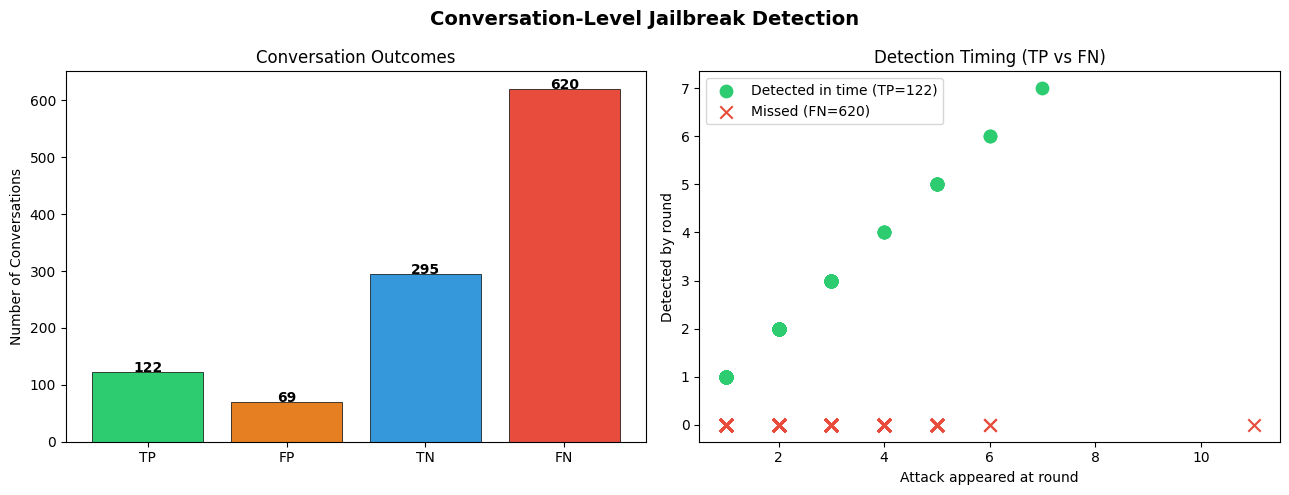

In [89]:
outcome_counts = conv_eval["outcome"].value_counts().reindex(
    ["TP", "FP", "TN", "FN"], fill_value=0
)
outcome_colors = {"TP": "#2ecc71", "TN": "#3498db", "FP": "#e67e22", "FN": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Conversation-Level Jailbreak Detection", fontsize=14, fontweight="bold")

# Plot 1: Outcome counts
axes[0].bar(
    outcome_counts.index,
    outcome_counts.values,
    color=[outcome_colors[k] for k in outcome_counts.index],
    edgecolor="black", linewidth=0.5
)
axes[0].set_title("Conversation Outcomes")
axes[0].set_ylabel("Number of Conversations")
for i, (k, v) in enumerate(outcome_counts.items()):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Plot 2: Detection timing
tp_convs = conv_eval[conv_eval["outcome"] == "TP"]
fn_convs = conv_eval[conv_eval["outcome"] == "FN"]
if len(tp_convs) > 0:
    axes[1].scatter(tp_convs["first_attack_round"], tp_convs["first_attack_round"],
                    color="#2ecc71", label=f"Detected in time (TP={len(tp_convs)})",
                    s=80, zorder=3)
if len(fn_convs) > 0:
    axes[1].scatter(fn_convs["first_attack_round"], [0]*len(fn_convs),
                    color="#e74c3c", label=f"Missed (FN={len(fn_convs)})",
                    s=80, marker="x", zorder=3)
axes[1].set_xlabel("Attack appeared at round")
axes[1].set_ylabel("Detected by round")
axes[1].set_title("Detection Timing (TP vs FN)")
axes[1].legend()

plt.tight_layout()
plt.savefig("conv_level_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

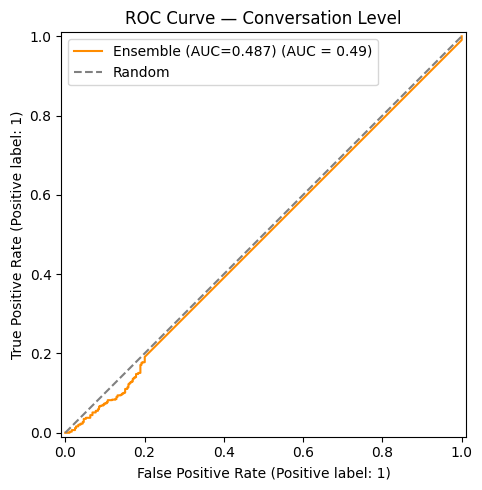

In [90]:
# ROC curve at conversation level
conv_scores_merge = df.groupby("conv_id")["ensemble_score"].max().reset_index()
conv_scores_merge = conv_scores_merge.merge(conv_eval[["conv_id","conv_true_label"]], on="conv_id")

if conv_scores_merge["conv_true_label"].nunique() > 1:
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(
        conv_scores_merge["conv_true_label"],
        conv_scores_merge["ensemble_score"],
        name=f"Ensemble (AUC={auc_conv:.3f})",
        ax=ax, color="darkorange"
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    ax.set_title("ROC Curve — Conversation Level")
    ax.legend()
    plt.tight_layout()
    plt.savefig("conv_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 11. EILOF-Inspired Streaming Mode
From the EILOF paper: *"only compute the LOF scores of new points without altering the LOF scores of existing points."*

In [91]:
# ── Section 11: EILOF-Inspired Streaming Mode ─────────────────────────────
# Use only labeled rows so X and df stay aligned.
labeled_mask   = df["label"] != -1
X_labeled_all  = X_combined[labeled_mask.values]
df_labeled_all = df[labeled_mask].reset_index(drop=True)

n_lab  = len(X_labeled_all)
split  = max(10, n_lab // 2)

X_train_s = X_labeled_all[:split]
X_new_s   = X_labeled_all[split:]

lof_stream = LocalOutlierFactor(
    n_neighbors=min(15, len(X_train_s) - 1),
    contamination=REAL_MALICIOUS_RATIO,
    novelty=True
)
lof_stream.fit(X_train_s)

stream_preds  = np.where(lof_stream.predict(X_new_s) == -1, 1, 0)
stream_scores = -lof_stream.score_samples(X_new_s)

stream_df = df_labeled_all.iloc[split:].copy().reset_index(drop=True)
stream_df["eilof_pred"]  = stream_preds
stream_df["eilof_score"] = stream_scores

print(f"Baseline turns (fitted)  : {split}")
print(f"Streaming turns (scored) : {len(X_new_s)}")
print(stream_df[["conv_id","round","label","eilof_score","eilof_pred"]].head(20).to_string())


Baseline turns (fitted)  : 1751
Streaming turns (scored) : 1752
    conv_id  round  label  eilof_score  eilof_pred
0       715      4      1     1.049071           1
1       715      5      1     1.069761           1
2       716      1      0     1.078905           1
3       716      2      1     1.014081           0
4       717      1      1     0.992332           0
5       718      1      0     1.035030           1
6       718      2      1     0.995913           0
7       719      1      0     1.123698           1
8       719      1      0     1.124961           1
9       719      2      1     1.132941           1
10      720      1      1     1.077609           1
11      721      1      1     1.086721           1
12      721      2      1     1.152722           1
13      721      3      1     1.042306           1
14      721      4      1     1.105048           1
15      722      1      0     1.034167           1
16      722      2      1     1.007203           0
17      723      1

---
## 12. Parameter Sensitivity: k vs Detection Rate

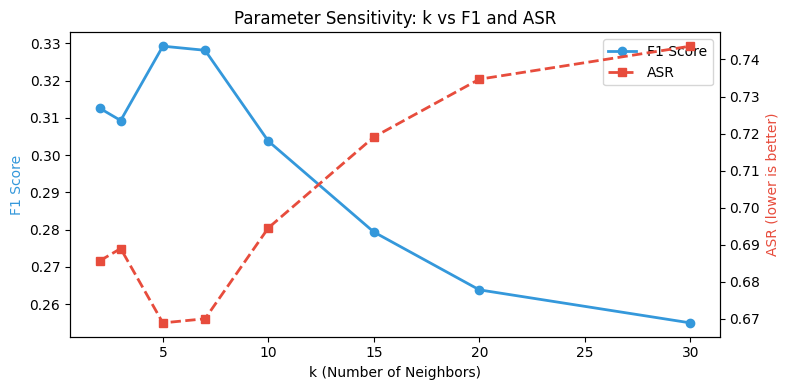

In [92]:
# ── Section 12: Parameter Sensitivity — k vs F1 / ASR ────────────────────
# For sensitivity analysis we use transductive LOF (fit_predict) on the full
# labeled set — this is intentional; we are measuring how k affects the
# detector's ability to separate the two classes, not generalisation.

labeled_mask_s = df["label"] != -1
X_labeled      = X_combined[labeled_mask_s.values]   # all labeled turns
y_true         = df.loc[labeled_mask_s, "label"].values

k_values  = [k for k in [2, 3, 5, 7, 10, 15, 20, 30] if k < len(X_labeled)]
f1_per_k  = []
asr_per_k = []

for k in k_values:
    lof_k   = LocalOutlierFactor(
        n_neighbors=k,
        contamination=REAL_MALICIOUS_RATIO,
        metric="cosine"
    )
    preds_k = np.where(lof_k.fit_predict(X_labeled) == -1, 1, 0)
    f1_k    = f1_score(y_true, preds_k, zero_division=0)
    tn_k, fp_k, fn_k, tp_k = confusion_matrix(y_true, preds_k, labels=[0, 1]).ravel()
    asr_k   = fn_k / (tp_k + fn_k) if (tp_k + fn_k) > 0 else 1.0
    f1_per_k.append(f1_k)
    asr_per_k.append(asr_k)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(k_values, f1_per_k,  marker="o", color="#3498db", label="F1 Score", linewidth=2)
ax2.plot(k_values, asr_per_k, marker="s", color="#e74c3c", label="ASR",      linewidth=2, linestyle="--")
ax1.set_xlabel("k (Number of Neighbors)")
ax1.set_ylabel("F1 Score", color="#3498db")
ax2.set_ylabel("ASR (lower is better)", color="#e74c3c")
ax1.set_title("Parameter Sensitivity: k vs F1 and ASR")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig("lof_k_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 13. Export Results

In [93]:
df.to_csv("turn_level_results.csv", index=False)
conv_eval.to_csv("conversation_level_results.csv", index=False)

total_convs   = len(conv_eval)
flagged_convs = conv_eval["conv_pred_label"].sum()
total_turns   = len(df)
flagged_turns = df["ensemble_pred"].sum()

print("Results exported: turn_level_results.csv, conversation_level_results.csv")
print("=" * 40)
print("FINAL DETECTION SUMMARY")
print("=" * 40)
print(f"  Total conversations  : {total_convs}")
print(f"  Flagged conversations: {flagged_convs} ({flagged_convs/total_convs*100:.1f}%)")
print(f"  Total turns          : {total_turns}")
print(f"  Flagged turns        : {flagged_turns} ({flagged_turns/total_turns*100:.1f}%)")
print(f"  Conversation F1      : {f1:.4f}")
print(f"  Conversation ASR     : {asr:.4f}")
print("=" * 40)

lof_report["final_summary"] = {
    "total_conversations": total_convs,
    "flagged_conversations": flagged_convs,
    "total_turns": total_turns,
    "flagged_turns": flagged_turns,
    "conversation_f1": f1,
    "conversation_asr": asr
}

Results exported: turn_level_results.csv, conversation_level_results.csv
FINAL DETECTION SUMMARY
  Total conversations  : 1106
  Flagged conversations: 191 (17.3%)
  Total turns          : 3503
  Flagged turns        : -2259.0 (-64.5%)
  Conversation F1      : 0.2615
  Conversation ASR     : 0.8356


In [94]:
# create file if not exist and write the lof_report dictionary to it


with open("../reports/lof_report.txt", "a", encoding="utf-8") as f:
    f.write(str(lof_report))

In [98]:
%pip install umap-learn


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 4.2 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.7 MB 4.0 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.6/38.1 MB 4.0 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/38.1 MB 3.9 MB/s eta 0:00:10
   --- ------------------------------------ 3.1/38.1 MB 3.9 MB/s eta 0:00:09
   ---- ----------------------------------- 3.9/38.1 MB 3.9 MB/s eta 0:00:09
   ---- ----------------------------------- 4.7/38.1 MB 3.9 MB/s eta 0:00:09
   ----- ---------------------------------- 5.5/38.1 MB 3.9 MB/s eta 0:00:09
   ------ ----------

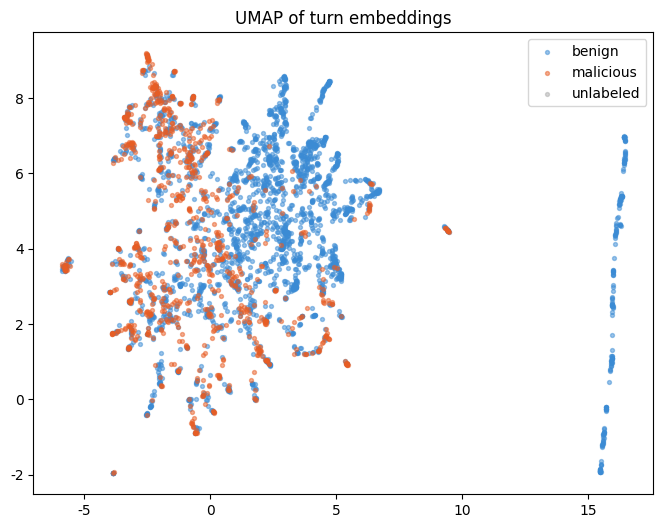

In [99]:
from umap import UMAP
reducer = UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(X_combined)

labeled = df["label"] != -1
plt.figure(figsize=(8,6))
colors = {0:"#3B8BD4", 1:"#E85D24", -1:"#aaa"}
for label, name in [(0,"benign"),(1,"malicious"),(-1,"unlabeled")]:
  mask = df["label"] == label
  plt.scatter(emb_2d[mask,0], emb_2d[mask,1],
    c=colors[label], label=name, s=8, alpha=0.5)
plt.legend(); plt.title("UMAP of turn embeddings")
plt.savefig("umap_embedding.png", dpi=150)

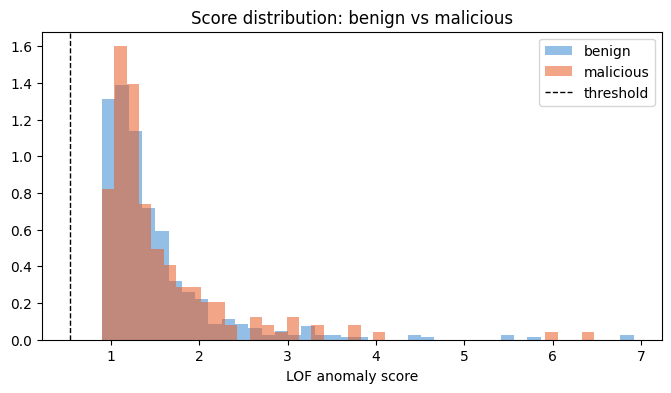

In [107]:
p99 = np.percentile(scores_labeled, 99)
mask_valid = scores_labeled < p99

plt.figure(figsize=(8,4))
for label, name, c in [(0,"benign","#3B8BD4"),(1,"malicious","#E85D24")]:
    mask = mask_valid & (y_lab == label)
    plt.hist(scores_labeled[mask], bins=40,
             alpha=0.55, color=c, label=name, density=True)

plt.axvline(threshold, color="black", ls="--", lw=1, label="threshold")
plt.xlabel("LOF anomaly score")
plt.title("Score distribution: benign vs malicious")
plt.legend()
plt.savefig("lof_score_dist.png", dpi=150)
plt.show()

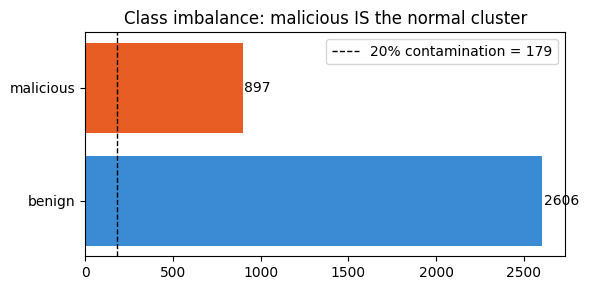

In [101]:
total = len(df[df["label"]!=-1])
n_mal = (df["label"]==1).sum()
n_ben = (df["label"]==0).sum()

fig, ax = plt.subplots(figsize=(6,3))
ax.barh(["benign","malicious"],[n_ben, n_mal],
  color=["#3B8BD4","#E85D24"])
ax.axvline(n_mal * 0.2, color="black", ls="--", lw=1,
  label=f"20% contamination = {int(n_mal*.2)}")
for i,(v) in enumerate([n_ben, n_mal]):
  ax.text(v+10, i, str(v), va="center", fontsize=10)
ax.set_title("Class imbalance: malicious IS the normal cluster")
ax.legend(); plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150)

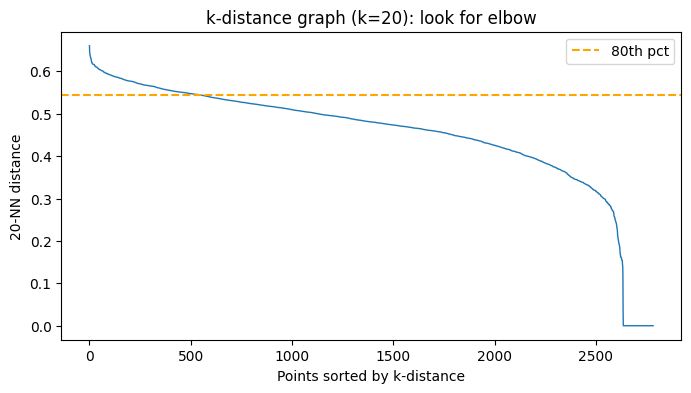

In [102]:
from sklearn.neighbors import NearestNeighbors

k = 20
nbrs = NearestNeighbors(n_neighbors=k,
  metric="cosine").fit(X_train)
dists, _ = nbrs.kneighbors(X_train)
k_dists = np.sort(dists[:, -1])[::-1] # kth neighbor dist

plt.figure(figsize=(8,4))
plt.plot(k_dists, linewidth=1)
plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"{k}-NN distance")
plt.title(f"k-distance graph (k={k}): look for elbow")
plt.axhline(np.percentile(k_dists,80), color="orange",
  ls="--", label="80th pct")
plt.legend()
plt.savefig("k_distance_graph.png", dpi=150)

# No clear elbow = uniform density = LOF cannot distinguish

If sim_bm ≈ sim_mm → classes not separable in this space
 benign↔benign : 0.0678
 mal↔mal : 0.0593
 cross-class : 0.0485


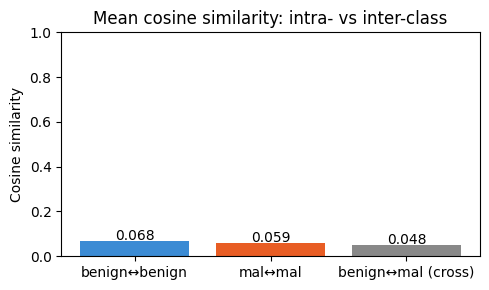

In [103]:
from sklearn.metrics.pairwise import cosine_similarity

# Sample for speed
idx_b = np.where(y_test == 0)[0][:100]
idx_m = np.where(y_test == 1)[0][:100]
X_b, X_m = X_test[idx_b], X_test[idx_m]

sim_bb = cosine_similarity(X_b, X_b).mean() # benign-benign
sim_mm = cosine_similarity(X_m, X_m).mean() # malicious-malicious
sim_bm = cosine_similarity(X_b, X_m).mean() # cross-class

fig, ax = plt.subplots(figsize=(5,3))
labels = ["benign↔benign", "mal↔mal", "benign↔mal (cross)"]
vals = [sim_bb, sim_mm, sim_bm]
colors = ["#3B8BD4", "#E85D24", "#888"]
bars = ax.bar(labels, vals, color=colors)
for bar, v in zip(bars, vals):
  ax.text(bar.get_x()+bar.get_width()/2, v+.005,
    f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Mean cosine similarity: intra- vs inter-class")
ax.set_ylabel("Cosine similarity")
plt.tight_layout()
plt.savefig("cosine_sim_analysis.png", dpi=150)

print(f"If sim_bm ≈ sim_mm → classes not separable in this space")
print(f" benign↔benign : {sim_bb:.4f}")
print(f" mal↔mal : {sim_mm:.4f}")
print(f" cross-class : {sim_bm:.4f}")